<h1> Experiment anti HOM probability against bandwith </h1>

In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.antiHOM_vs_bandwith import run_antiHOM_vs_bandwith

<h2> Execute the experiment </h2>

In [8]:
omega_A = 10*pi
Gamma = 5*pi

omega_ref_values = [omega_A, omega_A - Gamma/4, omega_A - Gamma/2]

nb_pts_bandwith = 15
lbda_tab = np.linspace(pi, 5*pi, nb_pts_bandwith)

for i in range(len(omega_ref_values)):
    index_experiment = i+1
    print("Running central frequency ", index_experiment, " out of ", len(omega_ref_values))
    lbda_tab, antiHOM_proba_tab = run_antiHOM_vs_bandwith(omega_ref_values[i], lbda_tab, index_experiment, 
                                                          store_results=True, progress=True)


Running central frequency  1  out of  3


100%|██████████| 15/15 [03:30<00:00, 14.02s/it]


Running central frequency  2  out of  3


100%|██████████| 15/15 [03:29<00:00, 13.96s/it]


Running central frequency  3  out of  3


100%|██████████| 15/15 [03:25<00:00, 13.71s/it]


<h2> Plot the results </h2>

Recover the data

In [9]:
antiHOM_proba = np.zeros((3, nb_pts_bandwith))
lbda_tab = np.zeros(nb_pts_bandwith)

for i in range(3):
    index_experiment = i+1
    data_file = f"../results/csv_files/antiHOM_vs_bandwith_{index_experiment}.csv"
    df = pd.read_csv(data_file)
    antiHOM_proba[i] = df['antiHOM_proba_tab'].to_numpy()

lbda_tab = df['lbda_tab'].to_numpy() #same lbda_tab for the three experiments

Generate the figure

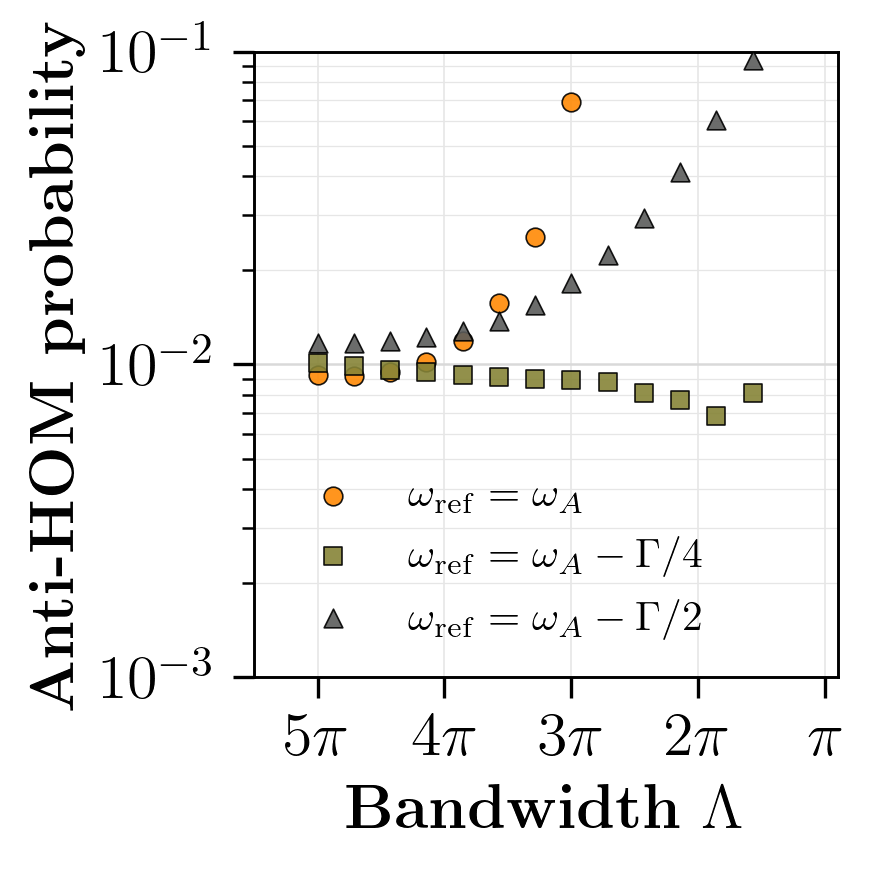

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Figure setup (même ADN que ta figure de référence)
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Palette sobre + markers distincts
colors  = ["#ff8a05", "#868437", "#5b5c5b"]
markers = ["o", "s", "^"]   # cercle, carré, triangle
labels  = [r'$\omega_{\rm ref} = \omega_A$', r'$\omega_{\rm ref} = \omega_A - \Gamma/4$', r'$\omega_{\rm ref} = \omega_A - \Gamma/2$']

# Scatter plots
for i in range(3):
    ax.scatter(
        lbda_tab,
        antiHOM_proba[i],
        s=20,
        marker=markers[i],
        color=colors[i],
        edgecolor='black',
        linewidth=0.4,
        alpha=0.9,
        zorder=3,
        label=labels[i]
    )

# Axes scaling and limits
ax.set_xlim(1.1 * lbda_tab[-1], 0.9 * lbda_tab[0])
ax.set_xticks([5*pi, 4*pi, 3*pi, 2*pi, pi])
ax.set_xticklabels([r"$5\pi$", r"$4\pi$", r"$3\pi$", r"$2\pi$", r"$\pi$"])

ax.set_yscale('log')
ax.set_ylim(1e-3, 1e-1)

# Labels
ax.set_xlabel(r'\textbf{Bandwidth} $\Lambda$', fontsize=15)
ax.set_ylabel(r'\textbf{Anti-HOM probability}', fontsize=15)

# --- Log scale ticks ---
ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(1,2,3,4,5,6,7,8,9)))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# --- Grid: fine horizontal grid on log scale ---
ax.grid(which='major', axis='y', color='0.85', linestyle='-', linewidth=0.6)
ax.grid(which='minor', axis='y', color='0.9', linestyle='-', linewidth=0.3)
ax.grid(which='major', axis='x', color='0.9', linestyle='-', linewidth=0.4)

# Legend (sobre, sans cadre)
ax.legend(prop={'size': 10}, frameon=False, loc="lower left")

# Tick appearance
ax.tick_params(axis='both', which='major', length=5, width=0.8)
ax.tick_params(axis='both', which='minor', length=3, width=0.6)

for item in ax.get_xticklabels() + ax.get_yticklabels():
    item.set_fontsize(15)

plt.tight_layout()
plt.show()